<a href="https://colab.research.google.com/github/Amans-sky/22MID0250/blob/main/OSEMN_Framework_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Customer.ID          Age           Gender     ItemPurchased 
 Min.   :   1.0   Min.   :18.00   Female:1248   Blouse : 171  
 1st Qu.: 975.8   1st Qu.:31.00   Male  :2652   Jewelry: 171  
 Median :1950.5   Median :44.00                 Pants  : 171  
 Mean   :1950.5   Mean   :44.07                 Shirt  : 169  
 3rd Qu.:2925.2   3rd Qu.:57.00                 Dress  : 166  
 Max.   :3900.0   Max.   :70.00                 Sweater: 164  
                                                (Other):2888  
        Category    PurchaseAmountInUSD       Location    Size     
 Accessories:1240   Min.   : 20.00      Montana   :  96   L :1053  
 Clothing   :1737   1st Qu.: 39.00      California:  95   M :1755  
 Footwear   : 599   Median : 60.00      Idaho     :  93   S : 663  
 Outerwear  : 324   Mean   : 59.76      Illinois  :  92   XL: 429  
                    3rd Qu.: 81.00      Alabama   :  89            
                    Max.   :100.00      Minnesota :  88            
                    

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



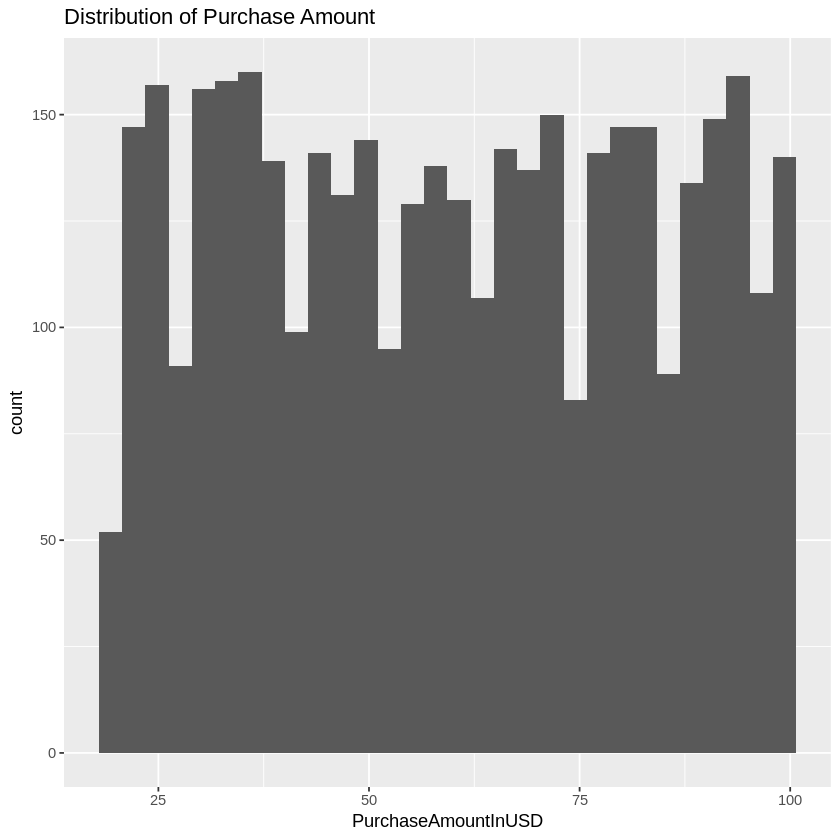


Call:
glm(formula = SubscriptionStatus ~ Age + Gender + PurchaseAmountInUSD + 
    PreviousPurchases + ReviewRating + PaymentMethod, family = binomial, 
    data = data)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)
(Intercept)              -1.958e+01  3.041e+02  -0.064    0.949
Age                       7.409e-04  2.599e-03   0.285    0.776
GenderMale                1.915e+01  3.041e+02   0.063    0.950
PurchaseAmountInUSD      -1.197e-04  1.672e-03  -0.072    0.943
PreviousPurchases         3.145e-03  2.774e-03   1.134    0.257
ReviewRating             -3.355e-02  5.575e-02  -0.602    0.547
PaymentMethodCash         3.045e-02  1.383e-01   0.220    0.826
PaymentMethodCredit Card  8.971e-02  1.365e-01   0.657    0.511
PaymentMethodDebit Card   1.366e-01  1.396e-01   0.979    0.328
PaymentMethodPayPal      -1.028e-01  1.405e-01  -0.732    0.464
PaymentMethodVenmo        2.443e-02  1.392e-01   0.175    0.861

(Dispersion parameter for binomial family tak

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages("pROC"):
“installation of package ‘pROC’ had non-zero exit status”
Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = No, case = Yes

Setting direction: controls < cases



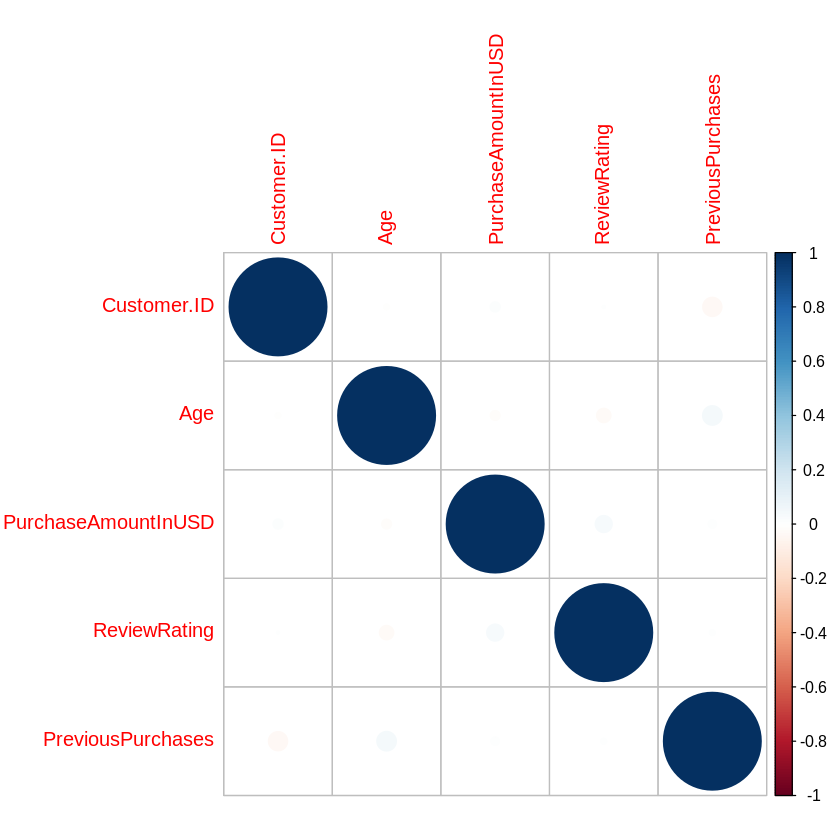

Area under the curve: 0.7321

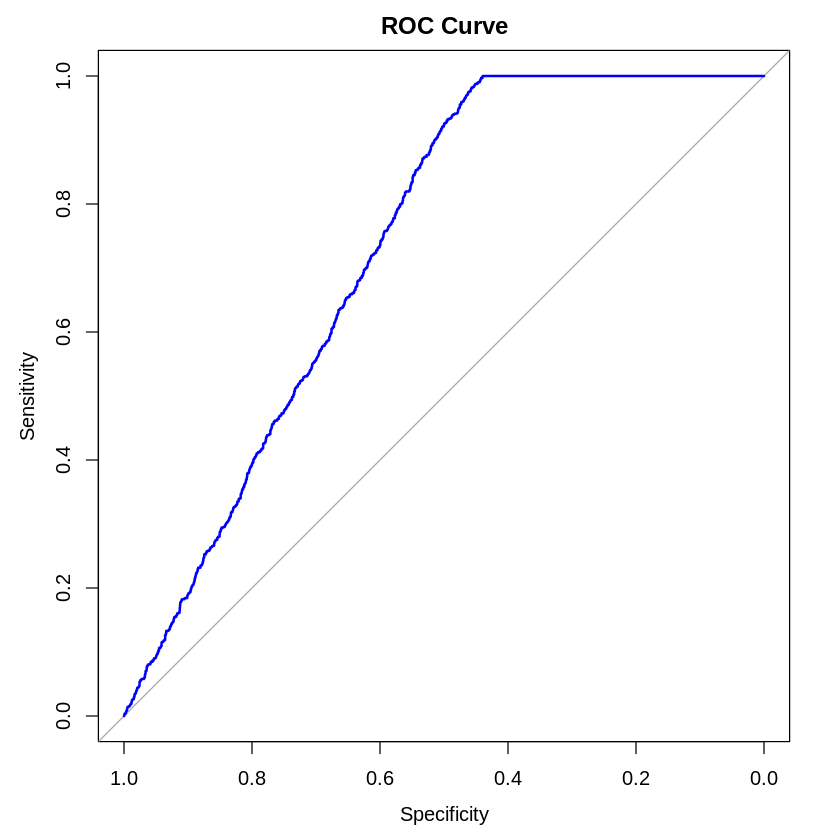

In [ ]:
# OSEMN Framework in R

# Step 1: OBTAIN - Load the dataset
data <- read.csv("/content/shopping_trends.csv")

# Step 2: SCRUB - Clean and preprocess the data
# Convert 'SubscriptionStatus' to a factor (binary outcome variable)
data$SubscriptionStatus <- as.factor(data$SubscriptionStatus)

# Convert categorical variables into factors
data$Gender <- as.factor(data$Gender)
data$ItemPurchased <- as.factor(data$ItemPurchased)
data$Category <- as.factor(data$Category)
data$Location <- as.factor(data$Location)
data$Size <- as.factor(data$Size)
data$Color <- as.factor(data$Color)
data$Season <- as.factor(data$Season)
data$PaymentMethod <- as.factor(data$PaymentMethod)
data$ShippingType <- as.factor(data$ShippingType)
data$PromoCodeUsed <- as.factor(data$PromoCodeUsed)
data$PreferredPaymentMethod <- as.factor(data$PreferredPaymentMethod)

# Check for missing values
missing_vals <- sum(is.na(data))
if(missing_vals > 0) {
  # Example strategy: Fill missing values (mean for numeric, mode for categorical)
  library(dplyr)
  data <- data %>%
    mutate_if(is.numeric, ~ifelse(is.na(.), mean(., na.rm = TRUE), .)) %>%
    mutate_if(is.factor, ~ifelse(is.na(.), as.factor(names(sort(table(.), decreasing=TRUE))[1]), .))
}

# Step 3: EXPLORE - Explore the data
summary(data) # General summary
library(ggplot2)
# Example: Visualize the distribution of PurchaseAmountInUSD
ggplot(data, aes(x = PurchaseAmountInUSD)) + geom_histogram(bins = 30) +
  labs(title = "Distribution of Purchase Amount")

# Correlation heatmap for numeric variables
#install.packages("corrplot")
library(corrplot)
numeric_data <- data[, sapply(data, is.numeric)]
cor_matrix <- cor(numeric_data, use="complete.obs")
corrplot(cor_matrix, method = "circle")

# Step 4: MODEL - Apply Logistic Regression
# Predicting 'SubscriptionStatus' using some independent variables
log_model <- glm(SubscriptionStatus ~ Age + Gender + PurchaseAmountInUSD + PreviousPurchases + ReviewRating + PaymentMethod,
                 data = data, family = binomial)

# Step 5: INTERPRET - Evaluate and interpret the model
summary(log_model) # Summary of the logistic regression model

# Model predictions
predicted_prob <- predict(log_model, type = "response")

# Convert probabilities to binary predictions (using 0.5 threshold)
predicted_class <- ifelse(predicted_prob > 0.5, 1, 0)

# Confusion matrix
#install.packages("caret")
library(caret)
#confusionMatrix(factor(predicted_class), data$SubscriptionStatus)

# ROC curve
install.packages("pROC")
library(pROC)
roc_curve <- roc(data$SubscriptionStatus, predicted_prob)
plot(roc_curve, col = "blue", main = "ROC Curve")
auc(roc_curve)


  Customer.ID           Age            PurchaseAmountInUSD  ReviewRating     
 Min.   :-1.7314   Min.   :-1.714174   Min.   :-1.678856   Min.   :-1.74520  
 1st Qu.:-0.8657   1st Qu.:-0.859338   1st Qu.:-0.876674   1st Qu.:-0.90747  
 Median : 0.0000   Median :-0.004502   Median : 0.009949   Median :-0.06974  
 Mean   : 0.0000   Mean   : 0.000000   Mean   : 0.000000   Mean   : 0.00000  
 3rd Qu.: 0.8657   3rd Qu.: 0.850335   3rd Qu.: 0.896571   3rd Qu.: 0.90761  
 Max.   : 1.7314   Max.   : 1.705171   Max.   : 1.698753   Max.   : 1.74534  
 PreviousPurchases 
 Min.   :-1.68556  
 1st Qu.:-0.85495  
 Median :-0.02433  
 Mean   : 0.00000  
 3rd Qu.: 0.87550  
 Max.   : 1.70612  

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



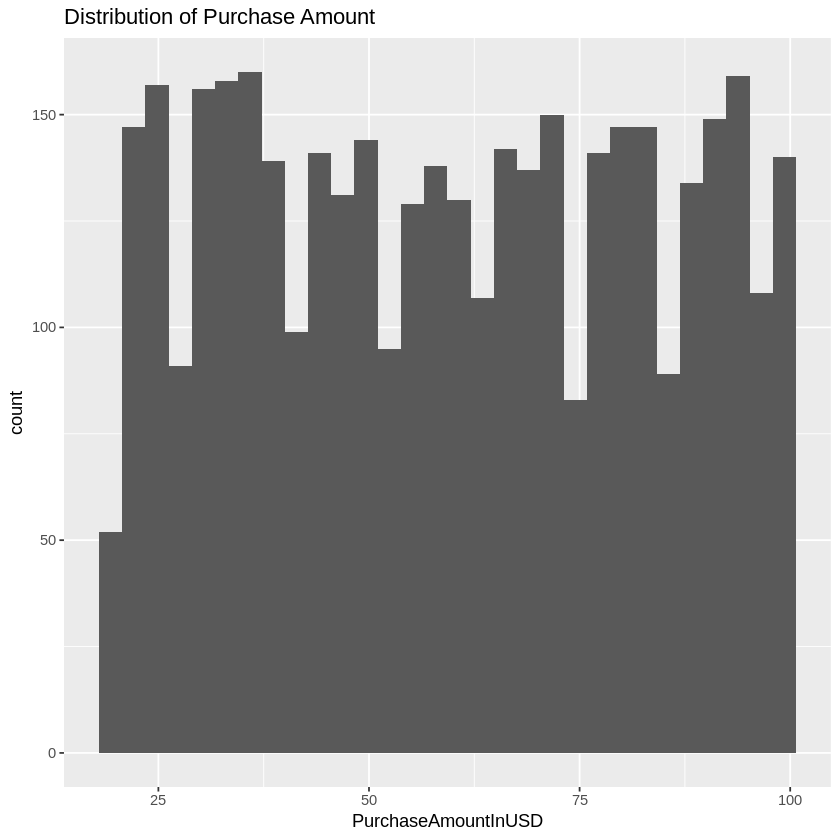

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


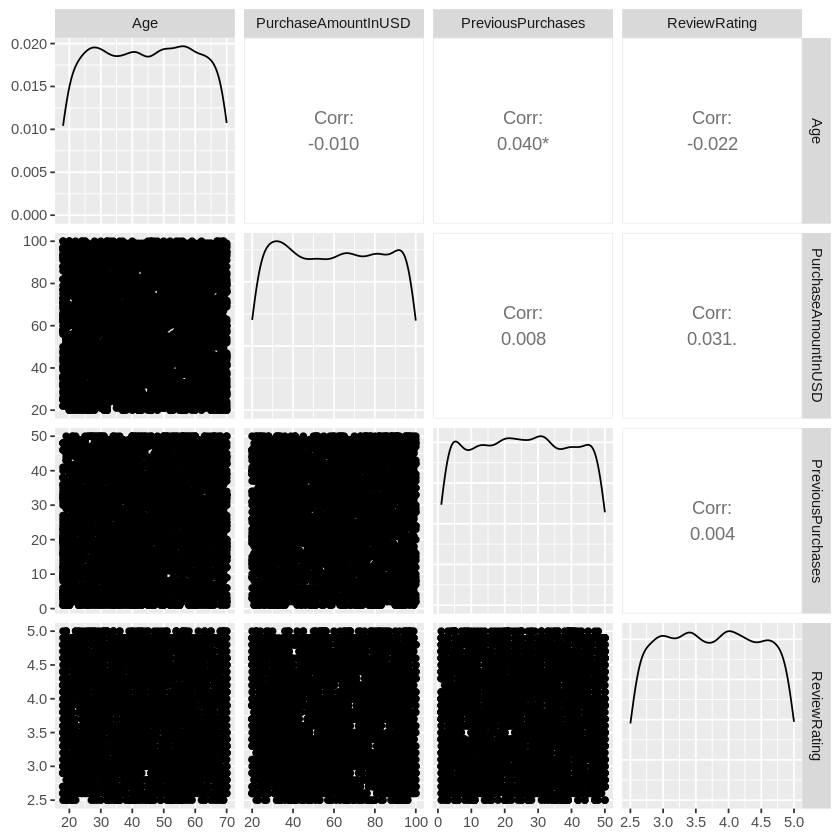


   1    2    3    4 
 971  940 1029  960 

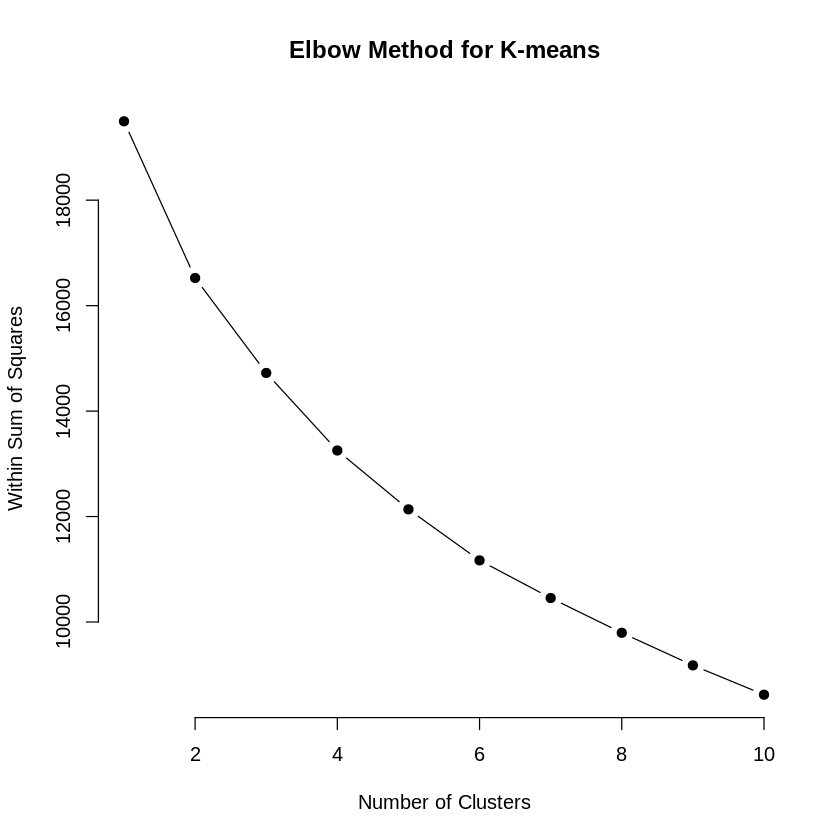

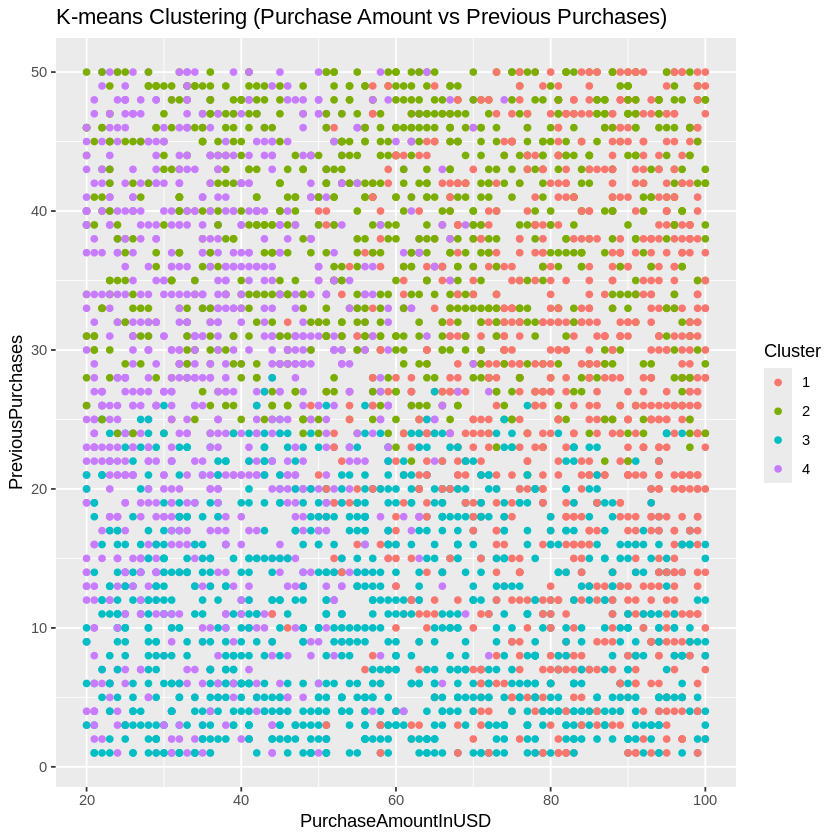

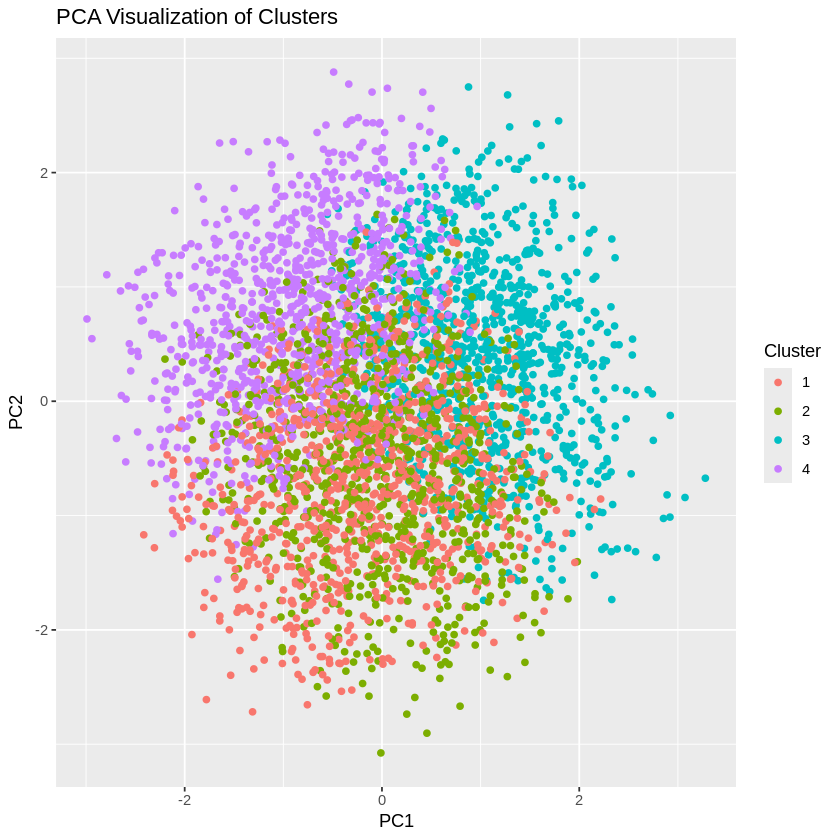

In [ ]:
# OSEMN Framework in R (K-means version)

# Step 1: OBTAIN - Load the dataset
data <- read.csv("/content/shopping_trends.csv")

# Step 2: SCRUB - Clean and preprocess the data
# Exclude non-numeric columns for K-means (since K-means works best on numeric data)
numeric_data <- data[, sapply(data, is.numeric)]

# Check for missing values and handle them
missing_vals <- sum(is.na(numeric_data))
if(missing_vals > 0) {
  # Fill missing values (mean for numeric)
  numeric_data <- numeric_data %>%
    mutate_if(is.numeric, ~ifelse(is.na(.), mean(., na.rm = TRUE), .))
}

# Scale numeric data (important for K-means to avoid bias from different ranges)
scaled_data <- scale(numeric_data)

# Step 3: EXPLORE - Explore the data
# Summary of numeric data
summary(scaled_data)

# Visualize distribution of important numeric variables
library(ggplot2)
ggplot(data, aes(x = PurchaseAmountInUSD)) +
  geom_histogram(bins = 30) + labs(title = "Distribution of Purchase Amount")

# Visualize a pairplot to check relationships (use a subset of numeric variables if dataset is large)
install.packages("GGally")
library(GGally)
ggpairs(data[, c("Age", "PurchaseAmountInUSD", "PreviousPurchases", "ReviewRating")])

# Step 4: MODEL - Apply K-means clustering
# Determine the optimal number of clusters using the elbow method
set.seed(123)  # For reproducibility
wss <- (nrow(scaled_data) - 1) * sum(apply(scaled_data, 2, var))

for (i in 2:10) {
  wss[i] <- sum(kmeans(scaled_data, centers = i, nstart = 20)$withinss)
}

# Plot the elbow curve
plot(1:10, wss, type = "b", pch = 19, frame = FALSE,
     xlab = "Number of Clusters", ylab = "Within Sum of Squares",
     main = "Elbow Method for K-means")

# Choose an appropriate number of clusters based on the elbow plot
k <- 4  # Suppose we choose 4 clusters from the elbow plot

# Apply K-means clustering
kmeans_model <- kmeans(scaled_data, centers = k, nstart = 20)

# Step 5: INTERPRET - Evaluate and interpret the clustering results
# Add the cluster labels to the original data
data$Cluster <- as.factor(kmeans_model$cluster)

# Summary of cluster assignments
table(data$Cluster)

# Visualize the clusters
ggplot(data, aes(x = PurchaseAmountInUSD, y = PreviousPurchases, color = Cluster)) +
  geom_point() + labs(title = "K-means Clustering (Purchase Amount vs Previous Purchases)")

# Principal Component Analysis (PCA) to reduce dimensions for better visualization
pca <- prcomp(scaled_data)
pca_data <- data.frame(pca$x[, 1:2], Cluster = data$Cluster)
ggplot(pca_data, aes(x = PC1, y = PC2, color = Cluster)) +
  geom_point() + labs(title = "PCA Visualization of Clusters")


  Customer.ID          Age           Gender     ItemPurchased 
 Min.   :   1.0   Min.   :18.00   Female:1248   Blouse : 171  
 1st Qu.: 975.8   1st Qu.:31.00   Male  :2652   Jewelry: 171  
 Median :1950.5   Median :44.00                 Pants  : 171  
 Mean   :1950.5   Mean   :44.07                 Shirt  : 169  
 3rd Qu.:2925.2   3rd Qu.:57.00                 Dress  : 166  
 Max.   :3900.0   Max.   :70.00                 Sweater: 164  
                                                (Other):2888  
        Category    PurchaseAmountInUSD       Location    Size     
 Accessories:1240   Min.   : 20.00      Montana   :  96   L :1053  
 Clothing   :1737   1st Qu.: 39.00      California:  95   M :1755  
 Footwear   : 599   Median : 60.00      Idaho     :  93   S : 663  
 Outerwear  : 324   Mean   : 59.76      Illinois  :  92   XL: 429  
                    3rd Qu.: 81.00      Alabama   :  89            
                    Max.   :100.00      Minnesota :  88            
                    

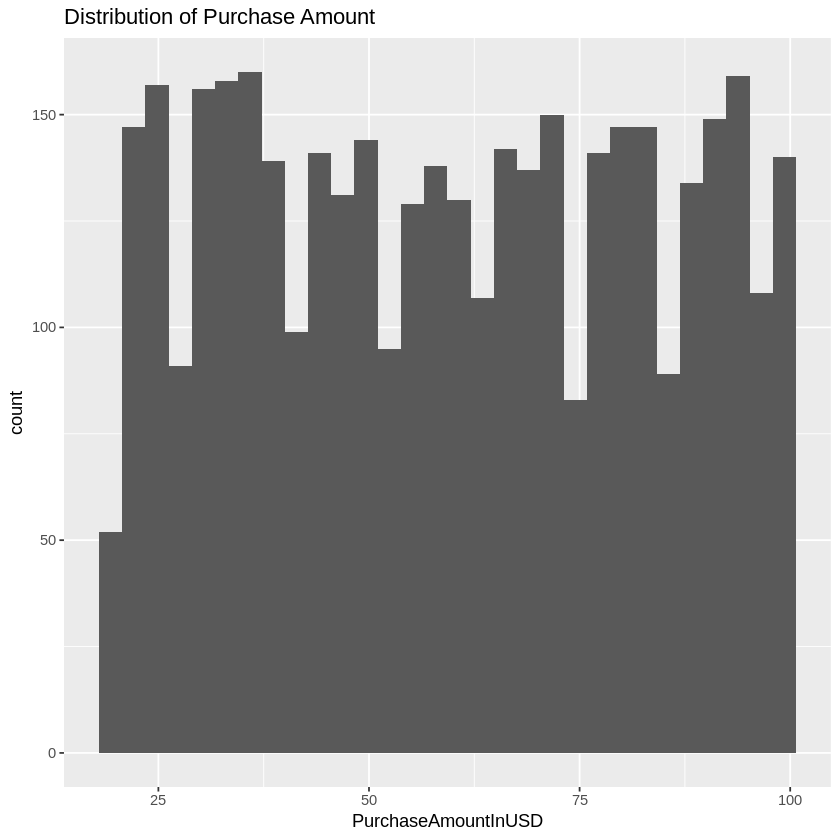

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  710  70
       Yes 136 254
                                          
               Accuracy : 0.8239          
                 95% CI : (0.8009, 0.8453)
    No Information Rate : 0.7231          
    P-Value [Acc > NIR] : 4.857e-16       
                                          
                  Kappa : 0.5863          
                                          
 Mcnemar's Test P-Value : 5.933e-06       
                                          
            Sensitivity : 0.8392          
            Specificity : 0.7840          
         Pos Pred Value : 0.9103          
         Neg Pred Value : 0.6513          
             Prevalence : 0.7231          
         Detection Rate : 0.6068          
   Detection Prevalence : 0.6667          
      Balanced Accuracy : 0.8116          
                                          
       'Positive' Class : No              
                              

Setting levels: control = No, case = Yes

Setting direction: controls < cases



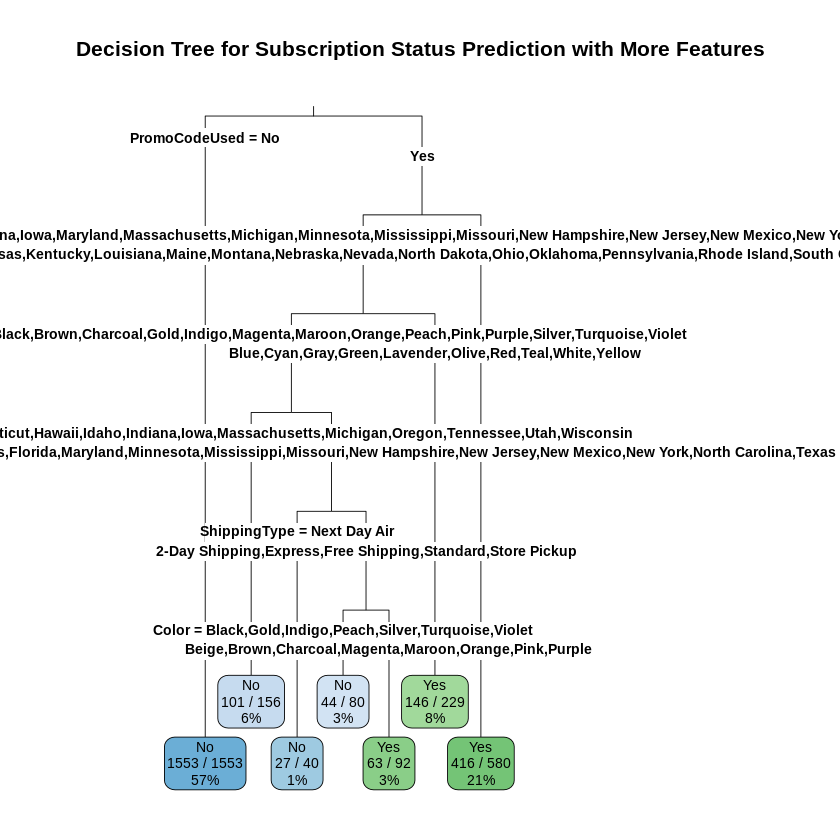

Area under the curve: 0.8918

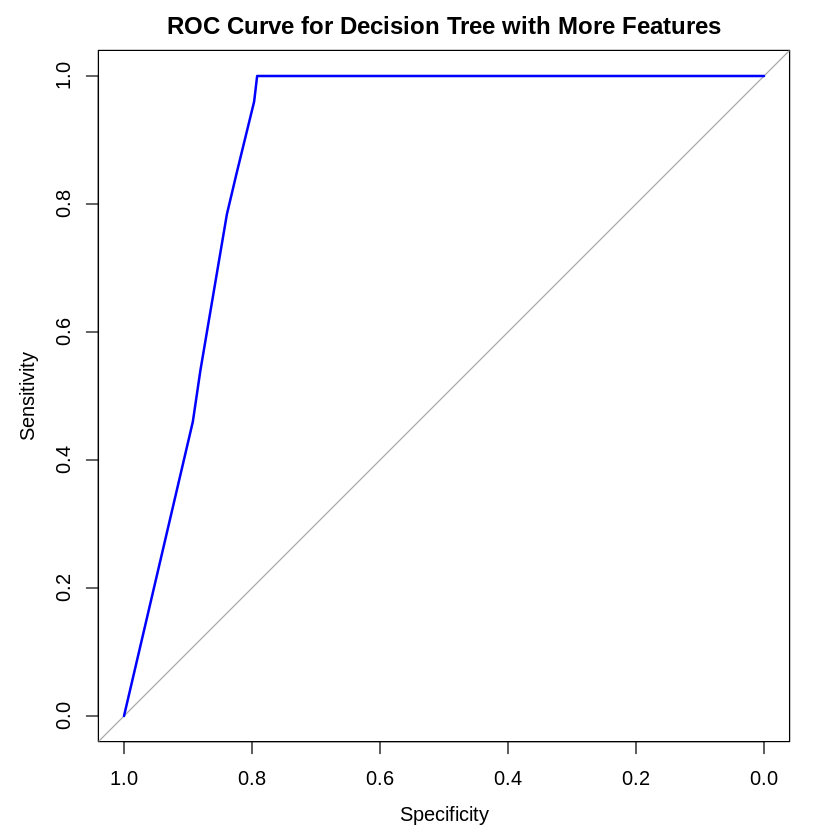

In [ ]:
# Install and load necessary packages
# install.packages("rpart")   # Decision trees
# install.packages("rpart.plot")  # For plotting trees
# install.packages("caret")   # For confusion matrix
# install.packages("pROC")    # For ROC curve
library(rpart)
library(rpart.plot)
library(caret)
library(pROC)

# Step 1: OBTAIN - Load the dataset
data <- read.csv("shopping_trends.csv")

# Step 2: SCRUB - Clean and preprocess the data
# Convert 'SubscriptionStatus' to a factor (target variable)
data$SubscriptionStatus <- as.factor(data$SubscriptionStatus)

# Convert categorical variables into factors
data$Gender <- as.factor(data$Gender)
data$ItemPurchased <- as.factor(data$ItemPurchased)
data$Category <- as.factor(data$Category)
data$Location <- as.factor(data$Location)
data$Size <- as.factor(data$Size)
data$Color <- as.factor(data$Color)
data$Season <- as.factor(data$Season)
data$PaymentMethod <- as.factor(data$PaymentMethod)
data$ShippingType <- as.factor(data$ShippingType)
data$PromoCodeUsed <- as.factor(data$PromoCodeUsed)
data$PreferredPaymentMethod <- as.factor(data$PreferredPaymentMethod)

# Check for missing values and handle them
missing_vals <- sum(is.na(data))
if(missing_vals > 0) {
  # Fill missing values (mean for numeric, mode for categorical)
  library(dplyr)
  data <- data %>%
    mutate_if(is.numeric, ~ifelse(is.na(.), mean(., na.rm = TRUE), .)) %>%
    mutate_if(is.factor, ~ifelse(is.na(.), as.factor(names(sort(table(.), decreasing=TRUE))[1]), .))
}

# Step 3: EXPLORE - Explore the data
# Summary of the dataset
summary(data)

# Example: Visualize the distribution of PurchaseAmountInUSD
library(ggplot2)
ggplot(data, aes(x = PurchaseAmountInUSD)) +
  geom_histogram(bins = 30) + labs(title = "Distribution of Purchase Amount")

# Step 4: MODEL - Apply Decision Tree
# Splitting data into training and testing sets (70% training, 30% testing)
set.seed(123)  # For reproducibility
train_index <- sample(1:nrow(data), 0.7 * nrow(data))
train_data <- data[train_index, ]
test_data <- data[-train_index, ]

# Fit decision tree model with more parameters
tree_model <- rpart(SubscriptionStatus ~ Age + Gender + PurchaseAmountInUSD + PreviousPurchases +
                    ReviewRating + PaymentMethod + Location + Size + Color + Season +
                    PromoCodeUsed + FrequencyofPurchases + DiscountApplied + ShippingType,
                    data = train_data, method = "class")

# Visualize the decision tree
rpart.plot(tree_model, type = 3, extra = 102, fallen.leaves = TRUE,
           main = "Decision Tree for Subscription Status Prediction with More Features")

# Step 5: INTERPRET - Evaluate the model
# Predict on the test set
test_pred <- predict(tree_model, newdata = test_data, type = "class")

# Confusion matrix
confusion_matrix <- confusionMatrix(test_pred, test_data$SubscriptionStatus)
print(confusion_matrix)

# Visualize feature importance
var_importance <- as.data.frame(varImp(tree_model))
print(var_importance)

# Plot ROC Curve
prob_pred <- predict(tree_model, newdata = test_data, type = "prob")[,2]
roc_curve <- roc(test_data$SubscriptionStatus, prob_pred)
plot(roc_curve, col = "blue", main = "ROC Curve for Decision Tree with More Features")
auc(roc_curve)
